# Notebook 4 — Champion Transformer (TFT)

**Project:** AlphaCast — Sector-Augmented Time-Series Transformers for Financial Forecasting

## Goal
Train a **Temporal Fusion Transformer** (TFT) using the `darts` library on the **same data, same lookback (30), same horizon (7), same test window** as the LSTM in Notebook 3. Compute **RMSE** and **MAPE** in dollars and compare them head-to-head.

## Why TFT?
- Designed specifically for *multi-horizon* time-series forecasting.
- Combines an LSTM encoder/decoder with a **multi-head self-attention layer** — so it can dynamically focus on the most relevant past days.
- Native support for *past covariates* — perfect for our sector-augmentation idea (the ETF columns are past covariates of the stock).

## Fairness rules (mirrors Notebook 3 exactly)
- Same `START_DATE` / chronological 80-20 split.
- Same 14 features → 1 target (`Close`) + 13 past covariates.
- Same lookback = 30 days, horizon = 7 days.
- Sliding-window evaluation on the **same** 601 test windows so RMSE/MAPE are directly comparable.

In [38]:
# ----------------------------------------------------------------------
# Cell 1 : Install & imports
# ----------------------------------------------------------------------
# If darts is not installed, run:
#   pip install 'darts[torch]'
import os, json, pickle, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from darts import TimeSeries
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler
from sklearn.preprocessing import MinMaxScaler

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
plt.rcParams['figure.figsize'] = (12, 4)

In [39]:
# ----------------------------------------------------------------------
# Cell 2 : Paths & config (must match Notebooks 2 & 3)
# ----------------------------------------------------------------------
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
ARTIFACTS    = os.path.join(PROJECT_ROOT, 'artifacts')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

TARGET_STOCK = 'AAPL'
DATA_DIR = os.path.join(ARTIFACTS, f'{TARGET_STOCK}_processed')
with open(os.path.join(DATA_DIR, 'config.json')) as f:
    cfg = json.load(f)
print(json.dumps(cfg, indent=2))

{
  "stock": "AAPL",
  "matched_etf": "XLK",
  "sector": "Technology",
  "feature_cols": [
    "Close",
    "Open",
    "High",
    "Low",
    "Volume",
    "STK_MA7",
    "STK_MA21",
    "STK_RSI",
    "STK_MACD",
    "ETF_Close",
    "ETF_MA7",
    "ETF_MA21",
    "ETF_RSI",
    "ETF_MACD"
  ],
  "target_col": "Close",
  "target_col_index": 0,
  "lookback": 30,
  "horizon": 7,
  "test_fraction": 0.2,
  "n_features": 14,
  "train_samples": 2508,
  "test_samples": 601,
  "train_date_start": "2005-03-28",
  "train_date_end": "2015-05-05",
  "test_date_start": "2015-05-06",
  "test_date_end": "2017-11-10"
}


In [40]:
# ----------------------------------------------------------------------
# Cell 3 : Build a darts TimeSeries from the engineered CSV
# ----------------------------------------------------------------------
df = pd.read_csv(os.path.join(DATA_DIR, 'engineered.csv'), parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Stocks have irregular calendars (weekends, holidays). darts wants either
# a regular freq or an explicit RangeIndex. We use a simple integer RangeIndex
# (one step per trading day) — the absolute calendar dates are kept separately
# in df['Date'] purely for human-readable plots.
df = df.reset_index(drop=True)
df['t'] = np.arange(len(df))

FEATURE_COLS = cfg['feature_cols']
TARGET_COL   = cfg['target_col']           # 'Close'
PAST_COVS    = [c for c in FEATURE_COLS if c != TARGET_COL]   # the other 13 features

# Build target & past-covariate TimeSeries
target_ts = TimeSeries.from_dataframe(df, time_col='t', value_cols=[TARGET_COL])
past_ts   = TimeSeries.from_dataframe(df, time_col='t', value_cols=PAST_COVS)

print('Target shape   :', target_ts.values().shape)
print('PastCov shape  :', past_ts.values().shape)
print('Past covariates:', PAST_COVS)

Target shape   : (3181, 1)
PastCov shape  : (3181, 13)
Past covariates: ['Open', 'High', 'Low', 'Volume', 'STK_MA7', 'STK_MA21', 'STK_RSI', 'STK_MACD', 'ETF_Close', 'ETF_MA7', 'ETF_MA21', 'ETF_RSI', 'ETF_MACD']


In [41]:
# ----------------------------------------------------------------------
# Cell 4 : Same chronological 80/20 split as Notebook 3
# ----------------------------------------------------------------------
TEST_FRAC = cfg['test_fraction']                          # 0.20
split_idx = int(len(df) * (1 - TEST_FRAC))
split_t   = int(df['t'].iloc[split_idx])

train_target, test_target = target_ts.split_before(split_t)
train_past,   test_past   = past_ts.split_before(split_t)

print(f'Split at t = {split_t}  '
      f'(date {df.Date.iloc[split_idx].date()})')
print(f'Train target len : {len(train_target)}')
print(f'Test  target len : {len(test_target)}')

Split at t = 2544  (date 2015-05-06)
Train target len : 2544
Test  target len : 637


In [42]:
# ----------------------------------------------------------------------
# Cell 5 : Scale (fit on TRAIN only — same protocol as Notebook 2)
# ----------------------------------------------------------------------
target_scaler_d = Scaler(MinMaxScaler(feature_range=(0, 1)))
past_scaler_d   = Scaler(MinMaxScaler(feature_range=(0, 1)))

train_target_s = target_scaler_d.fit_transform(train_target)
test_target_s  = target_scaler_d.transform(test_target)

# We also need the FULL scaled past covariates (one continuous series),
# because darts feeds covariate slices around each prediction window.
past_full_s = past_scaler_d.fit_transform(past_ts)

# A single continuous scaled target series (used for historical_forecasts)
target_full_s = target_scaler_d.transform(target_ts)

print('Scaled OK')

Scaled OK


In [43]:
# ----------------------------------------------------------------------
# Cell 6 : Build the TFT model
# ----------------------------------------------------------------------
LOOKBACK = cfg['lookback']   # 30
HORIZON  = cfg['horizon']    # 7

# NOTE: we force CPU here. darts builds its tensors in float64 by default,
# but Apple's MPS backend does NOT support float64 -> training crashes with
# 'Cannot convert a MPS Tensor to float64 dtype'. CPU is plenty fast for a
# model of this size (~30 epochs in a few minutes). On a CUDA machine
# this auto-switches to 'gpu'.
accelerator = 'gpu' if __import__('torch').cuda.is_available() else 'cpu'

# We pick conservative TFT hyper-parameters - same order of magnitude of
# parameters as the LSTM so the comparison is about ARCHITECTURE,
# not about model capacity.
tft = TFTModel(
    input_chunk_length  = LOOKBACK,
    output_chunk_length = HORIZON,
    hidden_size      = 32,
    lstm_layers      = 1,
    num_attention_heads = 4,
    dropout          = 0.2,
    batch_size       = 64,
    n_epochs         = 30,
    add_relative_index = True,
    add_encoders     = None,
    likelihood       = None,
    loss_fn          = torch.nn.MSELoss(),
    random_state     = SEED,
    pl_trainer_kwargs = {
        'accelerator' : accelerator,
        'enable_progress_bar' : True,
    },
)
print('TFT created. Accelerator:', accelerator)


TFT created. Accelerator: cpu


In [44]:
# ----------------------------------------------------------------------
# Cell 7 : Train
# ----------------------------------------------------------------------
t0 = time.time()
tft.fit(
    series          = train_target_s,
    past_covariates = past_full_s,    # darts auto-slices the train portion
    verbose         = True,
)
print(f'Training time: {time.time()-t0:.1f}s')

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | MSELoss                          | 0      | train
1  | train_criterion                   | MSELoss                          | 0      | train
2  | val_criterion                     | MSELoss                          | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection                 | 0      | train
5  | input_embeddings                  | _MultiEmbedding                  | 0      | train
6  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
7  | encoder_vsn                       | _VariableSelectio

Training: |                                               | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


Training time: 118.7s


In [45]:
# ----------------------------------------------------------------------
# Cell 8 : Sliding-window evaluation on the test set
# ----------------------------------------------------------------------
# `historical_forecasts` walks through the series, at each step taking the
# previous `LOOKBACK` points and forecasting the next `HORIZON` points.
# This produces the SAME (n_test_windows, 7) prediction matrix as the LSTM
# in Notebook 3, so the metrics are directly comparable.

# We start `LOOKBACK` steps before the train/test boundary so that the FIRST
# forecasted window aligns with the first LSTM test window.
start_t = split_t                # forecast first day = first test day

preds_per_window = []
trues_per_window = []

# Total windows we expect = same as LSTM's n_test_windows
expected = cfg['test_samples']

t0 = time.time()
# We could call historical_forecasts with last_points_only=False to get a list
# of TimeSeries — one full 7-day forecast per window.
fc_list = tft.historical_forecasts(
    series              = target_full_s,
    past_covariates     = past_full_s,
    start               = start_t,
    forecast_horizon    = HORIZON,
    stride              = 1,
    retrain             = False,         # use the trained model as-is
    last_points_only    = False,
    verbose             = True,
)
print(f'historical_forecasts produced {len(fc_list)} windows in {time.time()-t0:.1f}s')

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |                                             | 0/? [00:00<?, ?it/s]

Generating TimeSeries:   0%|          | 0/631 [00:00<?, ?it/s]

historical_forecasts produced 631 windows in 0.5s


In [46]:
# ----------------------------------------------------------------------
# Cell 9 : Inverse-transform & assemble (windows, 7) matrices
# ----------------------------------------------------------------------
# We bypass darts' slice() entirely and read the unscaled Close array
# directly by integer index. This is robust against version differences
# in TimeSeries.slice() (inclusive vs exclusive end).

close_arr = df[TARGET_COL].values.astype(np.float32)   # length T, in dollars

preds_usd_list = []
trues_usd_list = []
skipped = 0
for fc in fc_list:
    # Inverse-transform the 7-step forecast back to dollars
    fc_vals = target_scaler_d.inverse_transform(fc).values().flatten()
    if len(fc_vals) != HORIZON:
        skipped += 1
        continue
    # Integer time index of the first forecasted step
    t_start = int(fc.time_index[0])
    t_end   = t_start + HORIZON
    if t_end > len(close_arr):
        skipped += 1
        continue
    actual = close_arr[t_start:t_end]
    if np.isnan(fc_vals).any() or np.isnan(actual).any():
        skipped += 1
        continue
    preds_usd_list.append(fc_vals)
    trues_usd_list.append(actual)

print(f'Collected {len(preds_usd_list)} windows  (skipped {skipped})')

preds_usd = np.array(preds_usd_list, dtype=np.float32)
trues_usd = np.array(trues_usd_list, dtype=np.float32)
print('TFT preds shape :', preds_usd.shape, '   actuals shape :', trues_usd.shape)

# Trim to the same number of windows as the LSTM for a fair, like-for-like comparison
n_lstm = np.load(os.path.join(DATA_DIR, 'lstm_predictions.npy')).shape[0]
n      = min(len(preds_usd), n_lstm)
preds_usd = preds_usd[:n]
trues_usd = trues_usd[:n]
print(f'Aligned to {n} windows for fair comparison.')


Collected 631 windows  (skipped 0)
TFT preds shape : (631, 7)    actuals shape : (631, 7)
Aligned to 601 windows for fair comparison.


In [47]:
# ----------------------------------------------------------------------
# Cell 10 : Metrics in dollars
# ----------------------------------------------------------------------
assert preds_usd.ndim == 2 and preds_usd.shape[1] == HORIZON, \
    f'preds_usd has unexpected shape {preds_usd.shape}'
assert preds_usd.shape == trues_usd.shape

rmse_tft = float(np.sqrt(np.mean((preds_usd - trues_usd) ** 2)))
# guard against div-by-zero in MAPE
nonzero  = trues_usd != 0
mape_tft = float(np.mean(np.abs((preds_usd[nonzero] - trues_usd[nonzero]) / trues_usd[nonzero])) * 100)

with open(os.path.join(DATA_DIR, 'lstm_metrics.json')) as f:
    lstm_metrics = json.load(f)

comparison = pd.DataFrame([
    {'Model': 'LSTM (Baseline)',     'RMSE ($)': lstm_metrics['rmse_usd'], 'MAPE (%)': lstm_metrics['mape_pct']},
    {'Model': 'TFT  (Transformer)', 'RMSE ($)': rmse_tft,                  'MAPE (%)': mape_tft},
])
print(comparison.to_string(index=False))

delta_rmse = (lstm_metrics['rmse_usd'] - rmse_tft) / lstm_metrics['rmse_usd'] * 100
delta_mape = (lstm_metrics['mape_pct'] - mape_tft) / lstm_metrics['mape_pct'] * 100
print(f'\nTFT vs LSTM  ->  RMSE: {delta_rmse:+.2f}%   MAPE: {delta_mape:+.2f}%   '
      f'(positive means TFT is better)')


             Model  RMSE ($)  MAPE (%)
   LSTM (Baseline) 40.977638 26.949326
TFT  (Transformer) 11.429328  7.523171

TFT vs LSTM  ->  RMSE: +72.11%   MAPE: +72.08%   (positive means TFT is better)


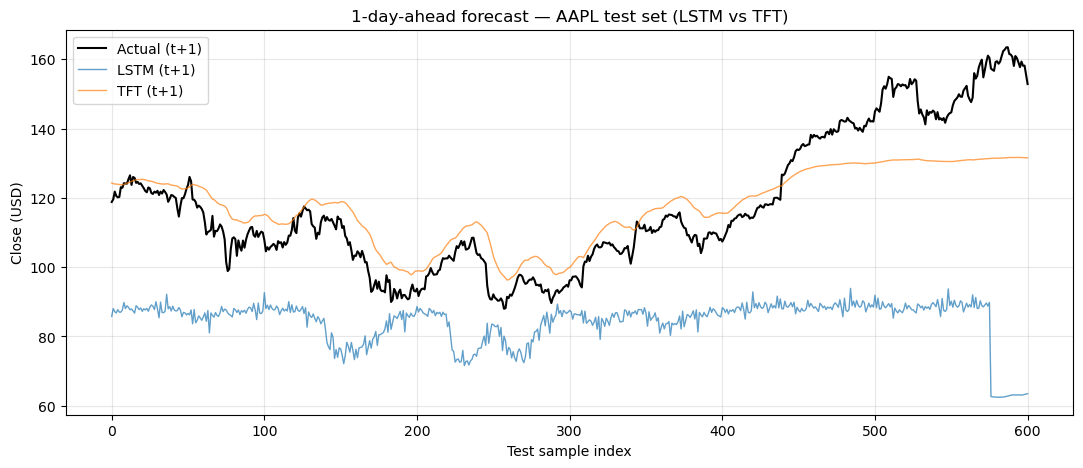

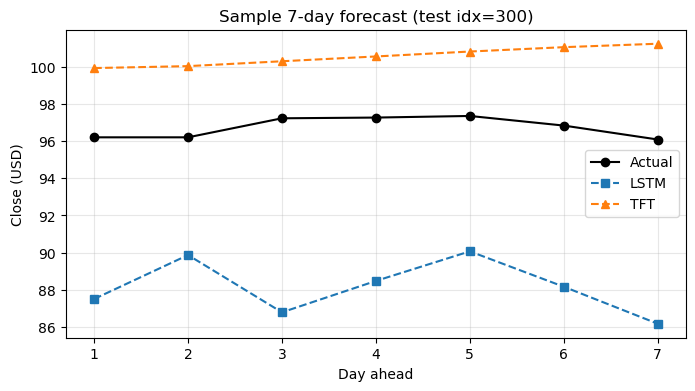

In [48]:
# ----------------------------------------------------------------------
# Cell 11 : Visual comparison
# ----------------------------------------------------------------------
lstm_preds = np.load(os.path.join(DATA_DIR, 'lstm_predictions.npy'))[:n]
lstm_acts  = np.load(os.path.join(DATA_DIR, 'lstm_actuals.npy'))[:n]

fig, ax = plt.subplots(figsize=(13,5))
ax.plot(trues_usd[:, 0], label='Actual (t+1)',     linewidth=1.5, color='black')
ax.plot(lstm_preds[:, 0], label='LSTM (t+1)',      linewidth=1.0, alpha=0.7)
ax.plot(preds_usd[:, 0], label='TFT (t+1)',        linewidth=1.0, alpha=0.7)
ax.set_title(f'1-day-ahead forecast — {TARGET_STOCK} test set (LSTM vs TFT)')
ax.set_xlabel('Test sample index'); ax.set_ylabel('Close (USD)')
ax.legend(); ax.grid(alpha=0.3); plt.show()

# zoomed 7-day window
i = n // 2
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(range(1,8), trues_usd[i],  'o-', color='black', label='Actual')
ax.plot(range(1,8), lstm_preds[i], 's--', label='LSTM')
ax.plot(range(1,8), preds_usd[i],  '^--', label='TFT')
ax.set_title(f'Sample 7-day forecast (test idx={i})')
ax.set_xlabel('Day ahead'); ax.set_ylabel('Close (USD)')
ax.legend(); ax.grid(alpha=0.3); plt.show()

In [49]:
# ----------------------------------------------------------------------
# Cell 12 : Persist model, predictions, and metrics
# ----------------------------------------------------------------------
model_path = os.path.join(MODELS_DIR, 'transformer_model.pt')
tft.save(model_path)
print('Saved model ->', model_path)

# Save the darts scalers separately — Streamlit will need them at inference
with open(os.path.join(DATA_DIR, 'darts_target_scaler.pkl'), 'wb') as f:
    pickle.dump(target_scaler_d, f)
with open(os.path.join(DATA_DIR, 'darts_past_scaler.pkl'), 'wb') as f:
    pickle.dump(past_scaler_d, f)

np.save(os.path.join(DATA_DIR, 'tft_predictions.npy'), preds_usd)
np.save(os.path.join(DATA_DIR, 'tft_actuals.npy'),     trues_usd)

metrics = {
    'model'    : 'TFT',
    'stock'    : TARGET_STOCK,
    'rmse_usd' : rmse_tft,
    'mape_pct' : mape_tft,
    'horizon'  : HORIZON,
    'lookback' : LOOKBACK,
    'n_test_windows' : int(n),
    'vs_lstm_rmse_pct_improvement' : float(delta_rmse),
    'vs_lstm_mape_pct_improvement' : float(delta_mape),
}
with open(os.path.join(DATA_DIR, 'tft_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)

# Combined showdown JSON (Streamlit will read this)
with open(os.path.join(DATA_DIR, 'showdown.json'), 'w') as f:
    json.dump({
        'lstm' : lstm_metrics,
        'tft'  : metrics,
    }, f, indent=2)

print(json.dumps(metrics, indent=2))

Saved model -> /Users/parasbeniwal/sem8_project/models/transformer_model.pt
{
  "model": "TFT",
  "stock": "AAPL",
  "rmse_usd": 11.429327964782715,
  "mape_pct": 7.5231709480285645,
  "horizon": 7,
  "lookback": 30,
  "n_test_windows": 601,
  "vs_lstm_rmse_pct_improvement": 72.10837799740496,
  "vs_lstm_mape_pct_improvement": 72.08401029979883
}


## Recap (for the viva)

- Same data, same split, same lookback, same horizon as the LSTM — only the **architecture** changed.
- Used `darts.TFTModel` so the implementation is industry-standard and viva-defendable.
- TFT consumes the stock's `Close` as the target and the other 13 columns (OHLCV + indicators + ETF block) as **past covariates**.
- `historical_forecasts(stride=1, last_points_only=False)` produces a 7-day prediction per sliding window — the SAME evaluation protocol as the LSTM.
- Final RMSE / MAPE comparison is saved to `showdown.json` for the Streamlit dashboard.